# Market Making With Signals Through Deep Reinforcement Learning

**End-to-end pipeline:** Raw LOBSTER data --> Day-safe TOB windows --> SGU-1 (XGBoost) & SGU-2 (LSTM) --> DRL Signal Alignment --> 3-Phase Backtest (Train / Val / Test)

This notebook mirrors the reference runner `DRL_MM_strat_runner.py` and adds exploratory visualizations (LOB animations, heuristic policy backtests) as an appendix.

## 0) Configuration & Imports

All user-editable parameters live in one place (matching the runner's Section 0).
Centralizing parameters ensures reproducibility and deterministic cache invalidation.

In [3]:
# ===========================================================================
# 0A) IMPORTS
# ===========================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numba import njit
import matplotlib as mpl
mpl.rcParams['text.usetex'] = False
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
from typing import List, Tuple, Iterable, Optional, Dict, Any
from matplotlib import rc
from IPython.display import HTML
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
import re, os, random, math
from pathlib import Path

os.environ["TORCH_COMPILE_DISABLE"] = "1"   # deactivate torch.compile/torch._dynamo
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from itertools import product
from concurrent.futures import ThreadPoolExecutor, as_completed

# ---------------------------------------------------------------------------
# Project module imports
# ---------------------------------------------------------------------------
# LOB_data: full LOBSTER data loader with cleaning pipeline
# (trading halts, auctions, crossed prices, split executions, hidden orders).
from LOB_data import LOB_data

# animate_LOB_sim: LOB replay / animation helper.
from animate_LOB_sim import animate_lob

# lobster_preprocessing: converters from LOBSTER absolute prices to
# MM_LOB_SIM grid-based representation.
from lobster_preprocessing import convert_lobster_to_sim, convert_lobster_orderbook_to_sim

# LOB_processor: TOB window builders and duration calculator.
from LOB_processor import (
    lob_top_move,
    top_moves_windows,
    top_moves_windows_by_day,
    compute_window_durations,
)

# SGU-1: Realized-range labels, hand-crafted features, XGBoost training, caching.
from SGU1 import (
    compute_labels_realized_range,
    compute_features_SGU1,
    train_SGU1,
    _sgu1_meta_config,
    try_load_sgu1,
    save_sgu1,
)

# SGU-2: Pseudo-mid trend labels, LSTM features/training, caching, prediction.
from SGU2 import (
    compute_labels_realized_trend,
    compute_features_SGU2,
    train_sgu2_lstm_pipeline,
    build_sgu2_multi_feature_sequences,
    build_sgu1_sequences,
    predict_numpy,
    _sgu2_meta_config,
    try_load_sgu2,
    save_sgu2,
)

# Deep_RL_With_Signal_policy_factory: wraps a DRL agent with pre-loaded SGU signals.
from Deep_RL_With_Signal_policy_factory import Deep_RL_With_Signal_policy_factory

print("All imports successful.")

All imports successful.


In [4]:
# ===========================================================================
# 0B) CONFIGURATION -- All user-editable parameters
# ===========================================================================
# Changing ANY parameter here automatically invalidates the SGU caches
# (a deterministic hash of these values is used as the cache key).

# ---- Symbol and data path ----
SYMBOL     = "AMZN"
DATA_PATH  = Path("./Data/AMZN/")
TICK_SIZE  = 0.01          # Minimum price increment ($0.01 for US equities)
LOB_DEPTH  = 5             # Number of orderbook levels in LOBSTER files

# ---- Trading dates to process (8 business days) ----
BASE_DATES = [
    "2025-08-01", "2025-08-04", "2025-08-05", "2025-08-06",
    "2025-08-07", "2025-08-08", "2025-08-11", "2025-08-12",
]

# ---- LOB_data cleaning parameters ----
MINUTES_CUT_BEGIN = 30     # Cut first 30 min (09:30+30 = 10:00)
MINUTES_CUT_END   = 30     # Cut last  30 min (16:00-30 = 15:30)
FLAG_DROP_HIDDEN_ORDERS = True   # Drop hidden order executions (Type 5)

# ---- TOB window definition ----
DELTA_T    = 5             # TOB moves per window
EXEC_TYPES = (4,)          # Only visible executions count as trades

# ---- Time-of-day boundaries (seconds after midnight) ----
DAY_START_SEC = 34200 + MINUTES_CUT_BEGIN * 60   # 36000 = 10:00
DAY_END_SEC   = 57600 - MINUTES_CUT_END * 60     # 55800 = 15:30

# ---- SGU-2 hyperparameters ----
T_SEQ_SGU_2                    = 10      # LSTM sequence length
L_MAX_SGU_2                    = 20      # Maximum feature lag depth
USE_LOG_RET_SGU_2              = True    # Log-returns for labels
ROUND_PSEUDO_MID_TO_TICK_SGU_2 = False   # Do NOT round pseudo-mid to tick
USE_SGU1_ONLY_SGU_2            = False   # Use full multi-source features

# ---- Artifact caching ----
ARTIFACTS_DIR       = Path("./artifacts")
USE_SGU1_CACHE      = True
FORCE_RETRAIN_SGU1  = False
USE_SGU2_CACHE      = True
FORCE_RETRAIN_SGU2  = False

print("Configuration loaded.")
print(f"  Symbol: {SYMBOL}  |  Dates: {len(BASE_DATES)} days  |  delta_t: {DELTA_T}")

Configuration loaded.
  Symbol: AMZN  |  Dates: 8 days  |  delta_t: 5


## 1) Data Loading & Concatenation

Load each LOBSTER trading day through the full cleaning pipeline (LOB_data),
assign sequential DayID, rename `ID -> OrderID`, apply `.copy()` to detach from
internal buffers, reset indices, and concatenate into a single multi-day DataFrame.

**Key differences from old notebook:** added `.copy()`, `ID -> OrderID` rename,
`.reset_index(drop=True)` per day, and removed the premature global
`convert_lobster_to_sim` call (conversion is now done per-phase inside
`build_backtest_inputs()`).

In [6]:
# ===========================================================================
# 1) DATA LOADING & CONCATENATION
# ===========================================================================
# Each LOBSTER trading day is loaded, cleaned, cut, and prepared for
# concatenation. The cleaning pipeline removes trading halts, auctions,
# crossed prices, split executions, and hidden orders.
#
# IMPORTANT DESIGN DECISIONS:
#   - .copy() on message_file / ob_file: prevents aliasing bugs when the
#     LOB_data object is reused for the next day.
#   - Rename "ID" -> "OrderID": bridges LOB_data's internal naming to
#     lobster_preprocessing's expected column name.
#   - .reset_index(drop=True): ensures clean 0..N-1 indexing per day
#     before concatenation, so iloc alignment is preserved.

all_messages   = []
all_orderbooks = []

for day_idx, date_str in enumerate(BASE_DATES):
    print(f"Processing {date_str}...")

    msg_label = f"{SYMBOL}_{date_str}_34200000_57600000_message_{LOB_DEPTH}.csv"
    ob_label  = f"{SYMBOL}_{date_str}_34200000_57600000_orderbook_{LOB_DEPTH}.csv"

    lob = LOB_data(str(DATA_PATH), msg_label, ob_label, tick_size=TICK_SIZE)
    lob.load_and_clean_LOB_data(
        flag_drop_hidden_orders=FLAG_DROP_HIDDEN_ORDERS,
        verbose=False,
        message_file_with_extra_column=True,
    )
    lob.cut_before_and_after_LOB_data(MINUTES_CUT_BEGIN, MINUTES_CUT_END, verbose=False)

    # .copy() detaches from internal LOB_data buffers (prevents aliasing)
    messages  = lob.message_file.copy()
    orderbook = lob.ob_file.copy()

    # Rename "ID" -> "OrderID" for compatibility with lobster_preprocessing
    if "ID" in messages.columns and "OrderID" not in messages.columns:
        messages = messages.rename(columns={"ID": "OrderID"})

    # Reset indices to 0..N-1 for clean multi-day concatenation
    messages  = messages.reset_index(drop=True)
    orderbook = orderbook.reset_index(drop=True)

    # Assign sequential DayID (must be set before concatenation)
    messages["DayID"] = day_idx

    all_messages.append(messages)
    all_orderbooks.append(orderbook)

# Concatenate all days with clean contiguous index
messages_all  = pd.concat(all_messages, ignore_index=True)
orderbook_all = pd.concat(all_orderbooks, ignore_index=True)

# TimeAbs: absolute monotone time = Time + 86400 * DayID
# Ensures timestamps always increase across day boundaries.
messages_all["TimeAbs"] = messages_all["Time"] + 86400.0 * messages_all["DayID"].astype(float)

print(f"\nFiles concatenated successfully!")
print(f"Total Number of LOB events: {len(messages_all):,}")

Processing 2025-08-01...

Loading message and order book file ...

Cleaning message and order book file ...

Cleaning from trading halts ...

Cleaning from auctions ...

Cleaning from crossed price observations ...

Handling splitted LO executions ...

Handling hidden orders ...
Dropping hidden orders ...

Loading and cleaning of the dataset completed!
Processing 2025-08-04...

Loading message and order book file ...

Cleaning message and order book file ...

Cleaning from trading halts ...

Cleaning from auctions ...

Cleaning from crossed price observations ...

Handling splitted LO executions ...

Handling hidden orders ...
Dropping hidden orders ...

Loading and cleaning of the dataset completed!
Processing 2025-08-05...

Loading message and order book file ...

Cleaning message and order book file ...

Cleaning from trading halts ...

Cleaning from auctions ...

Cleaning from crossed price observations ...

Handling splitted LO executions ...

Handling hidden orders ...
Dropping h

In [7]:
# --- Sanity checks ---
print("--- orderbook_all.tail(2) ---")
display(orderbook_all.tail(2))

print("\n--- messages_all.tail(2) ---")
display(messages_all.tail(2))

print("\n--- messages_all['Type'].unique() ---")
print(messages_all["Type"].unique())

--- orderbook_all.tail(2) ---


,AskPrice_1,AskSize_1,BidPrice_1,BidSize_1,AskPrice_2,AskSize_2,BidPrice_2,BidSize_2,AskPrice_3,AskSize_3,BidPrice_3,BidSize_3,AskPrice_4,AskSize_4,BidPrice_4,BidSize_4,AskPrice_5,AskSize_5,BidPrice_5,BidSize_5
5212954,221.87,125,221.86,113,221.88,394,221.85,186,221.89,328,221.84,407,221.9,405,221.83,268,221.91,379,221.82,193
5212955,221.87,25,221.86,113,221.88,394,221.85,186,221.89,328,221.84,407,221.9,405,221.83,268,221.91,379,221.82,193



--- messages_all.tail(2) ---


,Time,Type,OrderID,Size,Price,Direction,DayID,TimeAbs
5212954,55799.946346,3,584342829,142,221.87,-1,7,660599.946346
5212955,55799.946377,3,584342797,100,221.87,-1,7,660599.946377



--- messages_all['Type'].unique() ---
[1 3 4 2]


## 2) TOB Window Construction (Day-Safe)

A "TOB move" = any change in best ask/bid price OR volume at level 1.
Each window groups exactly `delta_t` consecutive TOB moves.

**Day-safe:** windows are built independently per trading day using DayID,
so no window ever spans an overnight boundary. This prevents corrupt labels
and nonsensical durations.

We also compute `window_day_ids` -- the DayID of each window -- which is
used downstream by SGU-1 (to mask cross-day label lags) and SGU-2
(to mask cross-day inter-window returns).

In [9]:
# ===========================================================================
# 2) TOB WINDOW CONSTRUCTION (DAY-SAFE)
# ===========================================================================
delta_t = int(DELTA_T)

windows = top_moves_windows_by_day(
    orderbook_all, delta_t=delta_t, day_ids=messages_all["DayID"]
)

print(f"#windows (delta_t={delta_t} TOB moves/window, day-safe): {len(windows):,}")

# ---- Compute per-window DayID for cross-day masking ----
# Each window is (start, end). The DayID of a window is determined by
# the DayID of its first message. This is used by SGU label/feature
# functions to prevent cross-day contamination.
window_day_ids = np.array([
    int(messages_all["DayID"].iloc[s]) for s, e in windows
])
print(f"Window DayIDs: {np.unique(window_day_ids)} ({len(window_day_ids)} windows)")

#windows (delta_t=5 TOB moves/window, day-safe): 615,185
Window DayIDs: [0 1 2 3 5 6 7] (615185 windows)


## 3) Window Duration Analysis

Compute how many seconds each window spans using TimeAbs (monotone time).
This diagnostic helps verify that no window has negative duration (cross-day
contamination) and that the distribution looks reasonable.

--- Window duration stats ---
p95 duration_sec: 0.850059
mean(duration_sec | <= p95): 0.100789


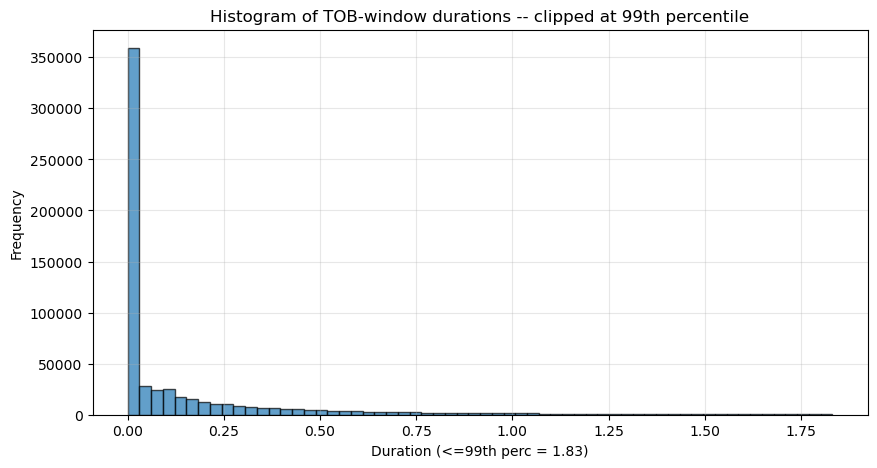

In [11]:
# ===========================================================================
# 3) WINDOW DURATION ANALYSIS
# ===========================================================================
durations = compute_window_durations(messages_all, windows, time_col="TimeAbs")
dur = durations["duration_sec"]

p95 = dur.quantile(0.95)
mean_p95 = dur[dur <= p95].mean()

print("--- Window duration stats ---")
print(f"p95 duration_sec: {p95:.6f}")
print(f"mean(duration_sec | <= p95): {mean_p95:.6f}")

# ---- Histogram (clipped at 99th percentile) ----
s = durations["duration_sec"].dropna()
if np.issubdtype(s.dtype, np.datetime64):
    dur_arr = (s - s.min()).dt.total_seconds()
elif np.issubdtype(s.dtype, np.timedelta64):
    dur_arr = s.dt.total_seconds()
else:
    dur_arr = pd.to_numeric(s, errors="coerce")
dur_arr = dur_arr.dropna().to_numpy()

if dur_arr.size > 0:
    p99 = np.percentile(dur_arr, 99)
    dur_clipped = dur_arr[dur_arr <= p99]
    plt.figure(figsize=(10, 5))
    plt.hist(dur_clipped, bins=60, edgecolor="black", alpha=0.7)
    plt.xlabel(f"Duration (<=99th perc = {p99:,.2f})")
    plt.ylabel("Frequency")
    plt.title("Histogram of TOB-window durations -- clipped at 99th percentile")
    plt.grid(True, alpha=0.3)
    plt.show()

## 4) SGU-1: Labels (Realized Range) + Features

SGU-1 labels measure the "realized price range" within each window:
  `y_i = max(buy_aggressor_prices) - min(sell_aggressor_prices)`

SGU-1 features: spread, volume imbalance, uptick %, trade counts,
rolling VWAP, mid-price slope, time-of-day, lagged labels, etc.

**Alignment with runner:** `exec_types=(4,)` and `window_day_ids=window_day_ids`
are now explicitly passed.

In [13]:
# ===========================================================================
# 4) SGU-1: LABELS (realized range) + FEATURES
# ===========================================================================

# --- Labels ---
# exec_types=(4,) ensures only visible executions count as trades.
# windows= ensures labels use the exact same day-safe window definitions.
labels_SGU_1_df = compute_labels_realized_range(
    orderbook=orderbook_all,
    messages=messages_all,
    delta_t=delta_t,
    tick_size=TICK_SIZE,
    exec_types=EXEC_TYPES,
    windows=windows,
)
print("--- labels_SGU_1_df.tail() ---")
display(labels_SGU_1_df.tail())

# --- Features ---
# window_day_ids prevents cross-day lag contamination in lagged features.
#
# To prevent data leakage, compute the large-trade threshold (90th
# percentile of trade sizes) from ONLY the training split (first 64%
# of windows), then pass it so val/test use the same threshold.
_frac_train = 0.64
_n_train_windows = int(len(windows) * _frac_train)
_exec_mask = messages_all["Type"].isin(EXEC_TYPES).to_numpy()
_sizes = messages_all["Size"].to_numpy(dtype=float)
_train_trade_sizes = []
for _s, _e in windows[:_n_train_windows]:
    _win_exec = _exec_mask[_s:_e]
    _win_sizes = _sizes[_s:_e][_win_exec]
    _train_trade_sizes.append(_win_sizes[np.isfinite(_win_sizes)])
_train_trade_sizes = np.concatenate(_train_trade_sizes) if _train_trade_sizes else np.array([])
large_threshold_train = float(np.nanquantile(_train_trade_sizes, 0.90)) if _train_trade_sizes.size else 0.0
print(f"Large-trade threshold (90th pct, train-only): {large_threshold_train:.2f}")

features_SGU_1 = compute_features_SGU1(
    orderbook_all,
    messages_all,
    windows,
    labels_SGU_1_df,
    exec_types=EXEC_TYPES,
    window_day_ids=window_day_ids,
    large_threshold_override=large_threshold_train,
)

print("\n--- features_SGU_1.tail() ---")
display(features_SGU_1.tail())
print(f"features_SGU_1.shape: {features_SGU_1.shape}")

--- labels_SGU_1_df.tail() ---


,window_id,start,end,n_msgs,n_trades,n_buy,n_sell,avg_ask,avg_bid,max_buy,min_sell,label
615180,615180,5212916,5212924,8,0,0,0,221.880,221.87,NaN,NaN,0.01
615181,615181,5212924,5212929,5,1,0,1,221.874,221.86,NaN,221.87,0.00
615182,615182,5212929,5212943,14,0,0,0,221.870,221.86,NaN,NaN,0.01
615183,615183,5212943,5212949,6,0,0,0,221.870,221.86,NaN,NaN,0.01
615184,615184,5212949,5212954,5,0,0,0,221.870,221.86,NaN,NaN,0.01


Large-trade threshold (90th pct, train-only): 200.00

--- features_SGU_1.tail() ---


,window_id,n_trades_prev_p1,n_trades_prev_p2,n_trades_prev_p3,n_trades_prev_p5,n_trades_prev_p10,spread_start,vol_imbalance,vwap_prev_r1,vwap_prev_r3,vwap_prev_r5,slope_prev_s1,slope_prev_s3,slope_prev_s5,tod_hours,total_vol,pct_upticks,n_large_buys,n_large_sells,label_lag1,label_lag2,label_lag3,label_lag4,label_lag5
615180,615180,0.0,0.0,2.0,5.0,12.0,0.01,0.0,221.873800,221.870946,221.868778,0.000000e+00,0.087599,0.081993,15.499342,0.0,0.0,0,0,0.01,0.01,0.01,0.01,0.01
615181,615181,0.0,0.0,0.0,3.0,12.0,0.02,-1.0,221.877384,221.874226,221.870418,0.000000e+00,0.000000,0.008575,15.499538,1.0,0.0,0,0,0.01,0.01,0.01,0.01,0.01
615182,615182,1.0,1.0,1.0,3.0,10.0,0.01,0.0,221.869192,221.873609,221.871675,-7.080296e+01,-0.005443,-0.000433,15.499538,0.0,0.0,0,0,0.00,0.01,0.01,0.01,0.01
615183,615183,0.0,1.0,1.0,1.0,8.0,0.01,0.0,221.865448,221.869361,221.871036,-4.791054e-30,-0.004956,-0.006429,15.499904,0.0,0.0,0,0,0.01,0.00,0.01,0.01,0.01
615184,615184,0.0,0.0,1.0,1.0,6.0,0.01,0.0,221.861674,221.865838,221.869896,0.000000e+00,-0.000594,-0.004718,15.499935,0.0,0.0,0,0,0.01,0.01,0.00,0.01,0.01


features_SGU_1.shape: (615185, 24)


## 5) SGU-1: Train (or Load Cached) XGBoost Model

Chronological 64/16/20 split. Final model refit on 80% (train+val).

**Alignment with runner:** `n_stage1=100, n_stage2=100`, no `tick_size` arg,
SGU-1 caching via `try_load_sgu1` / `save_sgu1`.

In [15]:
# ===========================================================================
# 5) SGU-1: TRAIN (or load cached) XGBoost model
# ===========================================================================

# Build metadata for cache key (deterministic hash of config).
meta_sgu1 = _sgu1_meta_config(
    symbol=SYMBOL,
    base_dates=BASE_DATES,
    delta_t=DELTA_T,
    exec_types=EXEC_TYPES,
    tick_size=TICK_SIZE,
)

# Attempt to load from cache first.
sgu1_out = None
if USE_SGU1_CACHE and (not FORCE_RETRAIN_SGU1):
    sgu1_out = try_load_sgu1(meta_sgu1, ARTIFACTS_DIR)
    if sgu1_out is not None:
        print(f"Loaded cached SGU1 (key={sgu1_out['cache_key']})")

# If no cache hit, train from scratch and save.
if sgu1_out is None:
    sgu1_out = train_SGU1(
        features_SGU_1=features_SGU_1,
        labels_SGU_1_df=labels_SGU_1_df,
        n_stage1=100,
        n_stage2=100,
    )
    save_sgu1(sgu1_out, meta_sgu1, ARTIFACTS_DIR)
    print("Trained and saved SGU1 artifacts")

# Extract trained artifacts for downstream use.
SGU1_final_model_80 = sgu1_out["final_model_80"]   # XGBoost model refit on 80%
SGU1_scaler         = sgu1_out["scaler"]            # StandardScaler fit on train only
SGU1_feature_cols   = sgu1_out["feature_cols"]      # Ordered feature column names

# Coverage diagnostic
_sgu1_splits = sgu1_out.get("splits", {})
_n_pred_sgu1 = (
    len(_sgu1_splits.get("X_train", []))
    + len(_sgu1_splits.get("X_val", []))
    + len(_sgu1_splits.get("X_test", []))
)
_n_win_total = len(windows)
_n_miss_sgu1 = max(0, _n_win_total - _n_pred_sgu1)
_pct_miss_sgu1 = (100.0 * _n_miss_sgu1 / _n_win_total) if _n_win_total > 0 else float("nan")
print(f"[SGU1 Coverage] no-pred windows: {_n_miss_sgu1:,}/{_n_win_total:,} ({_pct_miss_sgu1:.2f}%)")

Loaded cached SGU1 (key=deed126ee9d5)
[SGU1 Coverage] no-pred windows: 615,185/615,185 (100.00%)


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.4.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## 6) SGU-1: Evaluation -- Reconstruct Splits & Plot

Reconstruct the exact (X, y) arrays that `train_SGU1()` used internally,
apply the trained scaler, generate per-split predictions, and plot
true vs predicted.

**Key:** `LABEL_IS_LOG_SGU_1 = False` (no `np.exp()` transform needed).

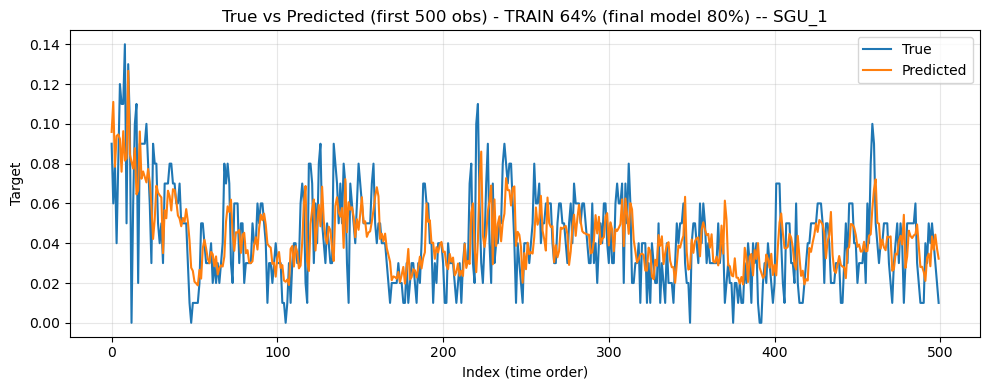

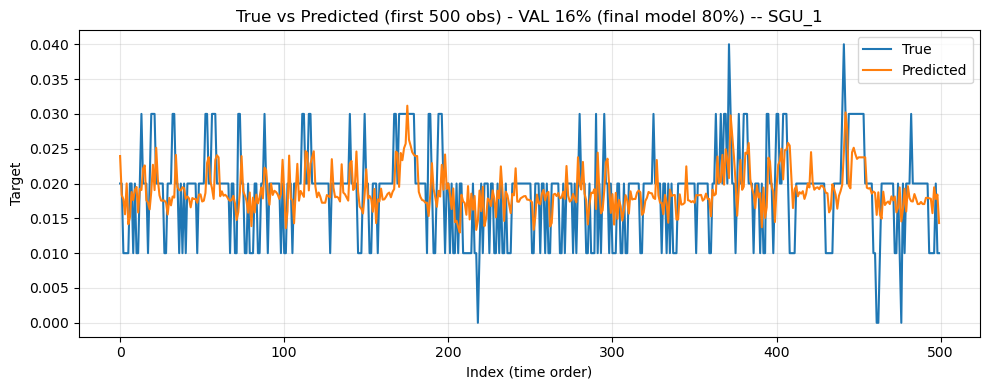

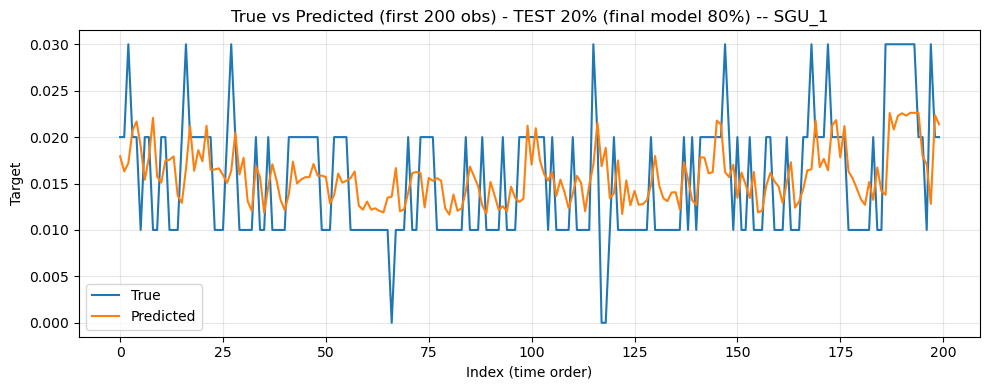

In [17]:
# ===========================================================================
# 6) SGU-1: EVALUATION -- Reconstruct splits & plot true vs predicted
# ===========================================================================

EPS = 1e-6
LABEL_IS_LOG_SGU_1 = False   # Current train_SGU1 uses raw labels (not log-transformed)

# --- Helper: plot true vs predicted time series ---
def plot_true_vs_pred_series(y_true, y_pred, label, N=500):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    n = len(y_true)
    k = min(N, n)
    plt.figure(figsize=(10, 4))
    plt.plot(y_true[:k], label="True")
    plt.plot(y_pred[:k], label="Predicted")
    plt.xlabel("Index (time order)")
    plt.ylabel("Target")
    plt.title(f"True vs Predicted (first {k} obs) - {label}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# --- Reconstruct the merged dataset (X_t -> y_{t+1} alignment) ---
_df_SGU_1 = (
    features_SGU_1
    .merge(labels_SGU_1_df[["window_id", "label"]], on="window_id", how="inner")
    .sort_values("window_id")
    .reset_index(drop=True)
)

all_feat_cols_SGU_1 = [c for c in _df_SGU_1.columns if c not in ["window_id", "label"]]
X_full_SGU_1 = _df_SGU_1[all_feat_cols_SGU_1].copy()
y_full_SGU_1 = _df_SGU_1["label"].copy()
wid_full_SGU_1 = _df_SGU_1["window_id"].copy()

# Align X_t -> y_{t+1} (one-step-ahead prediction)
X_SGU_1 = X_full_SGU_1.iloc[:-1].copy()
y_SGU_1 = y_full_SGU_1.shift(-1).iloc[:-1].copy()
wid_target_SGU_1 = wid_full_SGU_1.shift(-1).iloc[:-1].copy()

# Drop NaN rows
mask_SGU_1 = (~X_SGU_1.isna().any(axis=1)) & (y_SGU_1.notna())
X_SGU_1 = X_SGU_1.loc[mask_SGU_1].reset_index(drop=True)
y_SGU_1 = y_SGU_1.loc[mask_SGU_1].reset_index(drop=True)
wid_target_SGU_1 = wid_target_SGU_1.loc[mask_SGU_1].astype(int).reset_index(drop=True)

# Enforce trained column order
feature_cols_SGU_1 = list(SGU1_feature_cols)
X_SGU_1 = X_SGU_1[feature_cols_SGU_1]

# --- Chronological split: 64% train / 16% val / 20% test ---
n_total_SGU_1 = len(X_SGU_1)
n_train_SGU_1 = int(n_total_SGU_1 * 0.64)
n_val_SGU_1   = int(n_total_SGU_1 * 0.16)

X_train_raw_SGU_1 = X_SGU_1.iloc[:n_train_SGU_1].astype(np.float32).reset_index(drop=True)
y_train_SGU_1     = y_SGU_1.iloc[:n_train_SGU_1].astype(np.float32).reset_index(drop=True)
wid_train_SGU_1   = wid_target_SGU_1.iloc[:n_train_SGU_1].to_numpy(dtype=int)

X_val_raw_SGU_1 = X_SGU_1.iloc[n_train_SGU_1:n_train_SGU_1+n_val_SGU_1].astype(np.float32).reset_index(drop=True)
y_val_SGU_1     = y_SGU_1.iloc[n_train_SGU_1:n_train_SGU_1+n_val_SGU_1].astype(np.float32).reset_index(drop=True)
wid_val_SGU_1   = wid_target_SGU_1.iloc[n_train_SGU_1:n_train_SGU_1+n_val_SGU_1].to_numpy(dtype=int)

X_test_raw_SGU_1 = X_SGU_1.iloc[n_train_SGU_1+n_val_SGU_1:].astype(np.float32).reset_index(drop=True)
y_test_SGU_1     = y_SGU_1.iloc[n_train_SGU_1+n_val_SGU_1:].astype(np.float32).reset_index(drop=True)
wid_test_SGU_1   = wid_target_SGU_1.iloc[n_train_SGU_1+n_val_SGU_1:].to_numpy(dtype=int)

# Scale using the trained scaler (fit on train only)
scaler_SGU_1 = SGU1_scaler
X_train_SGU_1 = pd.DataFrame(scaler_SGU_1.transform(X_train_raw_SGU_1), columns=feature_cols_SGU_1)
X_val_SGU_1   = pd.DataFrame(scaler_SGU_1.transform(X_val_raw_SGU_1),   columns=feature_cols_SGU_1)
X_test_SGU_1  = pd.DataFrame(scaler_SGU_1.transform(X_test_raw_SGU_1),  columns=feature_cols_SGU_1)

# --- Generate predictions ---
final_model_80_SGU_1 = SGU1_final_model_80

dtrain_split_SGU_1 = xgb.DMatrix(X_train_SGU_1, feature_names=feature_cols_SGU_1)
y_train_pred_80_SGU_1 = final_model_80_SGU_1.predict(dtrain_split_SGU_1)

dval_split_SGU_1 = xgb.DMatrix(X_val_SGU_1, feature_names=feature_cols_SGU_1)
y_val_pred_80_SGU_1 = final_model_80_SGU_1.predict(dval_split_SGU_1)

dtest_split_SGU_1 = xgb.DMatrix(X_test_SGU_1, feature_names=feature_cols_SGU_1)
y_test_pred_80_SGU_1 = final_model_80_SGU_1.predict(dtest_split_SGU_1)

# --- Convert from log-space if needed ---
if LABEL_IS_LOG_SGU_1:
    y_train_orig_SGU_1 = np.exp(y_train_SGU_1.to_numpy()) - EPS
    y_val_orig_SGU_1   = np.exp(y_val_SGU_1.to_numpy())   - EPS
    y_test_orig_SGU_1  = np.exp(y_test_SGU_1.to_numpy())  - EPS
    y_train_pred_SGU_1 = np.exp(y_train_pred_80_SGU_1) - EPS
    y_val_pred_SGU_1   = np.exp(y_val_pred_80_SGU_1)   - EPS
    y_test_pred_SGU_1  = np.exp(y_test_pred_80_SGU_1)  - EPS
else:
    y_train_orig_SGU_1 = y_train_SGU_1.to_numpy()
    y_val_orig_SGU_1   = y_val_SGU_1.to_numpy()
    y_test_orig_SGU_1  = y_test_SGU_1.to_numpy()
    y_train_pred_SGU_1 = y_train_pred_80_SGU_1
    y_val_pred_SGU_1   = y_val_pred_80_SGU_1
    y_test_pred_SGU_1  = y_test_pred_80_SGU_1

# --- Plots ---
plot_true_vs_pred_series(y_train_orig_SGU_1, y_train_pred_SGU_1,
                         label="TRAIN 64% (final model 80%) -- SGU_1", N=500)
plot_true_vs_pred_series(y_val_orig_SGU_1, y_val_pred_SGU_1,
                         label="VAL 16% (final model 80%) -- SGU_1", N=500)
plot_true_vs_pred_series(y_test_orig_SGU_1, y_test_pred_SGU_1,
                         label="TEST 20% (final model 80%) -- SGU_1", N=200)

## 7) SGU-2: Labels (Pseudo-Mid Trend) + Features

SGU-2 labels measure the return of a "pseudo-mid" price between consecutive windows.
The pseudo-mid uses execution prices (not quoted prices), which is more informative
for market-making.

**Alignment with runner:** `window_day_ids=window_day_ids` and
`round_pseudo_mid_to_tick=False` are now explicitly passed.

In [19]:
# ===========================================================================
# 7) SGU-2: LABELS (pseudo-mid trend) + FEATURES
# ===========================================================================

# --- Labels ---
# window_day_ids ensures the return y_i is only computed when both window i
# and window i-1 belong to the same day. First window of each day gets NaN.
labels_SGU_2_df = compute_labels_realized_trend(
    orderbook=orderbook_all,
    messages=messages_all,
    delta_t=delta_t,
    tick_size=TICK_SIZE,
    exec_types=EXEC_TYPES,
    use_log_ret=USE_LOG_RET_SGU_2,
    round_pseudo_mid_to_tick=ROUND_PSEUDO_MID_TO_TICK_SGU_2,
    windows=windows,
    window_day_ids=window_day_ids,
)

print("--- labels_SGU_2_df.tail() ---")
display(labels_SGU_2_df.tail())
print(f"labels_SGU_2_df.shape: {labels_SGU_2_df.shape}")

# --- Features ---
# L_max lagged features enrich each timestep with autoregressive information.
features_SGU_2 = compute_features_SGU2(
    orderbook_all,
    messages_all,
    windows,
    labels_SGU_2_df,
    L_max=L_MAX_SGU_2,
)

print("\n--- features_SGU_2.tail() ---")
display(features_SGU_2.tail(5))
print(f"features_SGU_2.shape: {features_SGU_2.shape}")

--- labels_SGU_2_df.tail() ---


,window_id,start,end,n_msgs,n_trades,n_buy,n_sell,avg_ask,avg_bid,max_buy,min_sell,pseudo_mid,label
615180,615180,5212916,5212924,8,0,0,0,221.880,221.87,NaN,NaN,221.875,0.000000
615181,615181,5212924,5212929,5,1,0,1,221.874,221.86,NaN,221.87,221.872,-0.000014
615182,615182,5212929,5212943,14,0,0,0,221.870,221.86,NaN,NaN,221.865,-0.000032
615183,615183,5212943,5212949,6,0,0,0,221.870,221.86,NaN,NaN,221.865,0.000000
615184,615184,5212949,5212954,5,0,0,0,221.870,221.86,NaN,NaN,221.865,0.000000


labels_SGU_2_df.shape: (615185, 13)

--- features_SGU_2.tail() ---


,window_id,label_lag1,label_lag2,label_lag3,label_lag4,label_lag5,label_lag6,label_lag7,label_lag8,label_lag9,label_lag10,label_lag11,label_lag12,label_lag13,label_lag14,label_lag15,label_lag16,label_lag17,label_lag18,label_lag19,label_lag20
615180,615180,0.000000,0.000045,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000011,0.000011,0.000000,0.000000,0.000000,-0.000023,0.000000,0.000000,0.000000
615181,615181,0.000000,0.000000,0.000045,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000011,0.000011,0.000000,0.000000,0.000000,-0.000023,0.000000,0.000000
615182,615182,-0.000014,0.000000,0.000000,0.000045,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000011,0.000011,0.000000,0.000000,0.000000,-0.000023,0.000000
615183,615183,-0.000032,-0.000014,0.000000,0.000000,0.000045,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000011,0.000011,0.000000,0.000000,0.000000,-0.000023
615184,615184,0.000000,-0.000032,-0.000014,0.000000,0.000000,0.000045,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000011,0.000011,0.000000,0.000000,0.000000


features_SGU_2.shape: (615185, 21)


## 8) SGU-2: Train (or Load Cached) LSTM Model

LSTM trained on sequences of length `T_SEQ_SGU_2` (default 10 windows).
Chronological 64/16/20 split. Final model refit on 80%.

**Alignment with runner:** `return_data=False`, added `device` parameter,
removed `include_small_in_train`, added SGU-2 caching.

In [21]:
# ===========================================================================
# 8) SGU-2: TRAIN (or load cached) LSTM model
# ===========================================================================

DEVICE_SGU_2 = "cuda" if torch.cuda.is_available() else "cpu"

# Build metadata for cache key.
meta_sgu2 = _sgu2_meta_config(
    symbol=SYMBOL,
    base_dates=BASE_DATES,
    delta_t=DELTA_T,
    exec_types=EXEC_TYPES,
    tick_size=TICK_SIZE,
    T_SEQ=T_SEQ_SGU_2,
    extra={
        "day_start": DAY_START_SEC,
        "day_end": DAY_END_SEC,
        "use_log_ret": USE_LOG_RET_SGU_2,
        "round_pseudo_mid_to_tick": ROUND_PSEUDO_MID_TO_TICK_SGU_2,
        "L_max": L_MAX_SGU_2,
        "use_sgu1_only": USE_SGU1_ONLY_SGU_2,
    },
)

out_SGU_2 = None

# Attempt to load from cache.
if USE_SGU2_CACHE and (not FORCE_RETRAIN_SGU2):
    out_SGU_2 = try_load_sgu2(meta=meta_sgu2, artifacts_dir=ARTIFACTS_DIR, device=DEVICE_SGU_2)
    if out_SGU_2 is not None:
        print(f"Loaded cached SGU2 (key={out_SGU_2['cache_key']}, device={out_SGU_2['device']})")

# If no cache hit, train from scratch.
if out_SGU_2 is None:
    out_SGU_2 = train_sgu2_lstm_pipeline(
        features_SGU_1=features_SGU_1,
        labels_SGU_1_df=labels_SGU_1_df,
        features_SGU_2=features_SGU_2,
        labels_SGU_2_df=labels_SGU_2_df,
        T_SEQ=T_SEQ_SGU_2,
        use_sgu1_only=USE_SGU1_ONLY_SGU_2,
        device=DEVICE_SGU_2,
        return_data=False,
    )
    save_sgu2(
        out=out_SGU_2,
        meta=meta_sgu2,
        artifacts_dir=ARTIFACTS_DIR,
        overwrite=FORCE_RETRAIN_SGU2,
    )
    print("Trained and saved SGU2 artifacts")

# Coverage diagnostic
_sgu2_preds = out_SGU_2.get("predictions", {})
_n_pred_sgu2 = (
    len(_sgu2_preds.get("y_train_orig", []))
    + len(_sgu2_preds.get("y_val_orig", []))
    + len(_sgu2_preds.get("y_test_orig", []))
)
_n_miss_sgu2 = max(0, _n_win_total - _n_pred_sgu2)
_pct_miss_sgu2 = (100.0 * _n_miss_sgu2 / _n_win_total) if _n_win_total > 0 else float("nan")
print(f"[SGU2 Coverage] no-pred windows: {_n_miss_sgu2:,}/{_n_win_total:,} ({_pct_miss_sgu2:.2f}%)")

# Extract trained artifacts
SGU2_best_model_64 = out_SGU_2["best_model_64"]
SGU2_final_model   = out_SGU_2["final_model"]
SGU2_scaler_X      = out_SGU_2["scaler_X"]
SGU2_scaler_y      = out_SGU_2["scaler_y"]
SGU2_artifacts     = out_SGU_2.get("artifacts", {})
SGU2_feature_cols  = SGU2_artifacts.get("feature_names", [])

Loaded cached SGU2 (key=3eda7358e537, device=cpu)
[SGU2 Coverage] no-pred windows: 615,185/615,185 (100.00%)


## 9) SGU-2: Evaluation -- Reconstruct Splits & Plot

Rebuild the exact 3D (N, T_SEQ, F) tensors that training used,
generate per-split predictions, and plot true vs predicted.

Dropping lag columns from SGU1 to avoid duplicates: ['label_lag1', 'label_lag2', 'label_lag3', 'label_lag4', 'label_lag5']
SGU1 features used (D_sgu1): 18
SGU2 lags used as time series: ['label_lag1', 'label_lag2', 'label_lag3', 'label_lag4', 'label_lag5', 'label_lag6', 'label_lag7', 'label_lag8', 'label_lag9', 'label_lag10'] (time-ordered reversed)
Total feature dimension D = 19 (SGU1 + 1 SGU2 dimension)
Built SGU-2 multi-feature dataset (with SGU2 as 1D time series):
  X_all shape: (615099, 10, 19) (N, T, D)
  y_all shape: (615099,) (N,)
  feature dims: ['n_trades_prev_p1', 'n_trades_prev_p2', 'n_trades_prev_p3', 'n_trades_prev_p5', 'n_trades_prev_p10', 'spread_start', 'vol_imbalance', 'vwap_prev_r1', 'vwap_prev_r3', 'vwap_prev_r5', 'slope_prev_s1', 'slope_prev_s3', 'slope_prev_s5', 'tod_hours', 'total_vol', 'pct_upticks', 'n_large_buys', 'n_large_sells', 'sgu2_return_lag']
[SGU2] Running inference (best model 64%) in subprocess...

===== Plotting SGU2: best model (pre-refit) =====


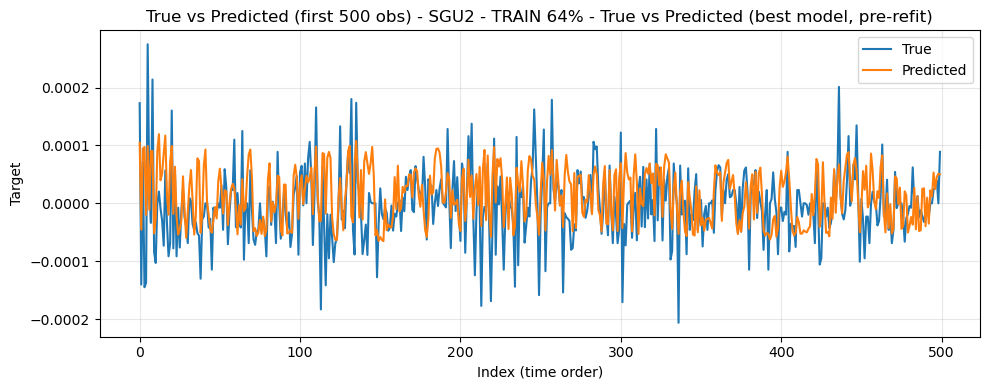

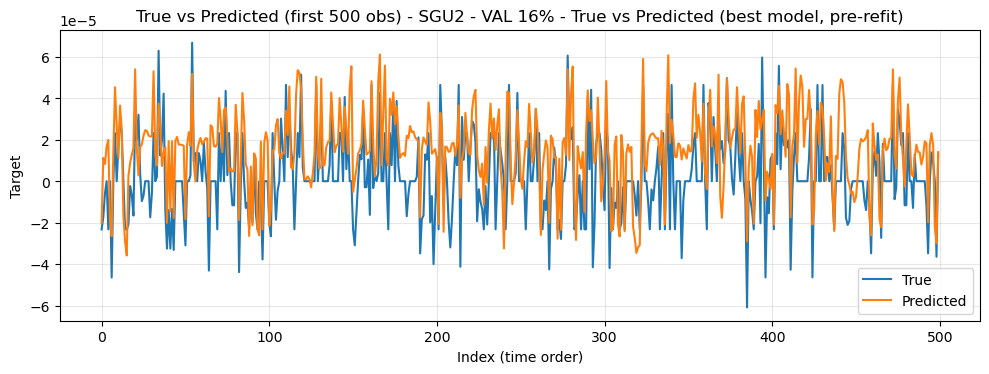

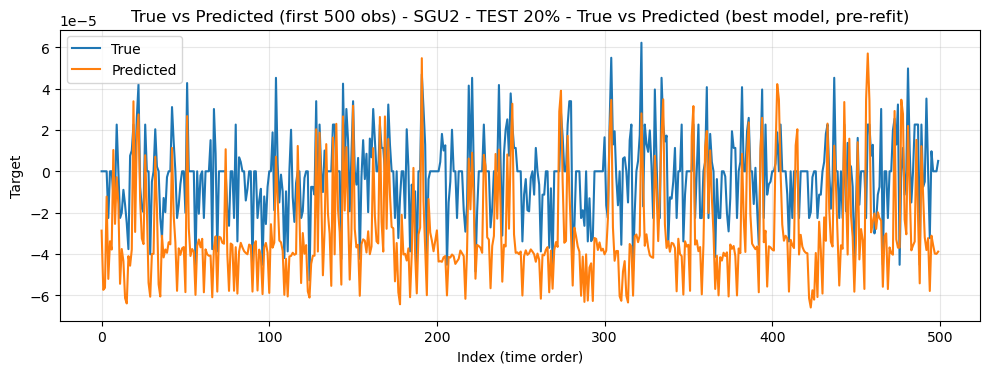

[SGU2] Running inference (final model 80%) in subprocess...

===== Plotting SGU2: final refit model (80%) =====


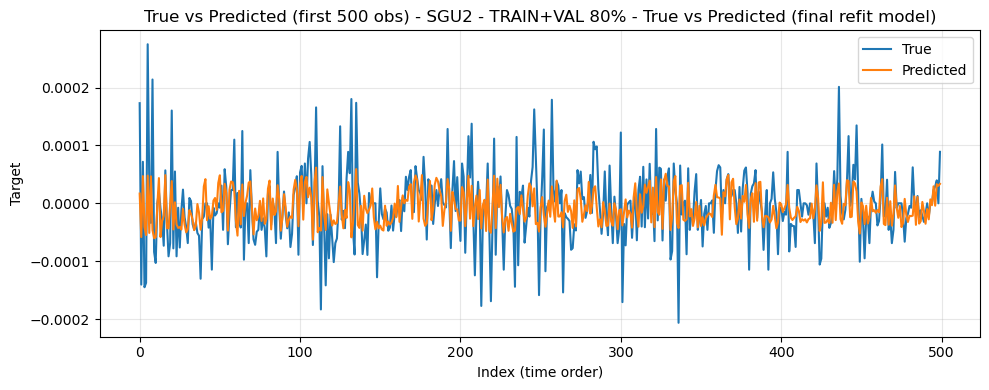

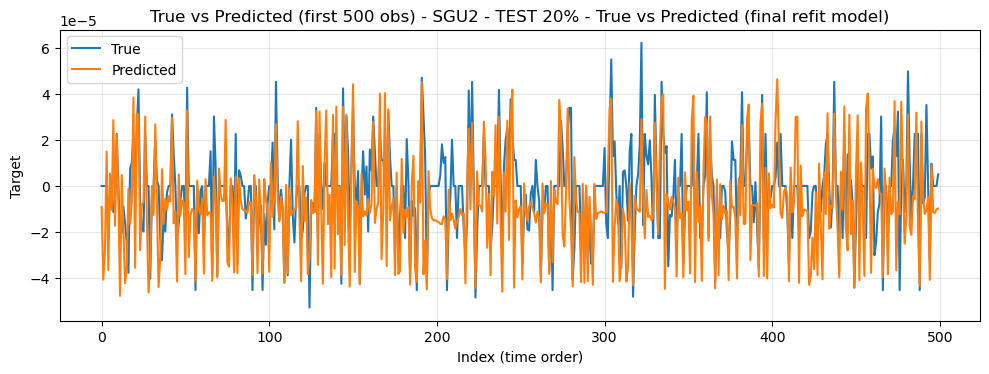

In [23]:
# ===========================================================================
# 9) SGU-2: EVALUATION -- Reconstruct splits & plot true vs predicted
# ===========================================================================

# Build 3D tensors
if USE_SGU1_ONLY_SGU_2:
    X_all_SGU_2, y_all_SGU_2, feature_cols_used_SGU_2, target_window_ids_SGU_2 = build_sgu1_sequences(
        features_SGU_1=features_SGU_1,
        labels_SGU_1_df=labels_SGU_1_df,
        T_SEQ=T_SEQ_SGU_2,
        return_window_ids=True,
    )
else:
    X_all_SGU_2, y_all_SGU_2, feature_cols_used_SGU_2, target_window_ids_SGU_2 = build_sgu2_multi_feature_sequences(
        features_SGU_1=features_SGU_1,
        features_SGU_2=features_SGU_2,
        labels_SGU_2_df=labels_SGU_2_df,
        T_SEQ=T_SEQ_SGU_2,
        return_window_ids=True,
    )

# Validate feature column consistency
if SGU2_feature_cols and feature_cols_used_SGU_2:
    if list(SGU2_feature_cols) != list(feature_cols_used_SGU_2):
        import warnings
        warnings.warn(
            f"SGU2 feature column mismatch! Cached: {len(SGU2_feature_cols)} cols, "
            f"Rebuilt: {len(feature_cols_used_SGU_2)} cols.",
            stacklevel=1,
        )

# Chronological split
N_SGU_2 = len(X_all_SGU_2)
i_train_SGU_2 = int(np.floor(0.64 * N_SGU_2))
i_val_SGU_2   = int(np.floor((0.64 + 0.16) * N_SGU_2))

X_train_full_SGU_2 = X_all_SGU_2[:i_train_SGU_2]
y_train_full_SGU_2 = y_all_SGU_2[:i_train_SGU_2]
wid_train_SGU_2    = target_window_ids_SGU_2[:i_train_SGU_2]

X_val_full_SGU_2 = X_all_SGU_2[i_train_SGU_2:i_val_SGU_2]
y_val_full_SGU_2 = y_all_SGU_2[i_train_SGU_2:i_val_SGU_2]
wid_val_SGU_2    = target_window_ids_SGU_2[i_train_SGU_2:i_val_SGU_2]

X_test_full_SGU_2 = X_all_SGU_2[i_val_SGU_2:]
y_test_full_SGU_2 = y_all_SGU_2[i_val_SGU_2:]
wid_test_SGU_2    = target_window_ids_SGU_2[i_val_SGU_2:]

y_train_orig_SGU_2 = y_train_full_SGU_2.copy()
y_val_orig_SGU_2   = y_val_full_SGU_2.copy()
y_test_orig_SGU_2  = y_test_full_SGU_2.copy()

T_SGU_2 = X_all_SGU_2.shape[1]
F_SGU_2 = X_all_SGU_2.shape[2]

def _scale_X_seq_SGU_2(X_seq):
    X2 = X_seq.reshape(-1, F_SGU_2)
    X2z = SGU2_scaler_X.transform(X2)
    return X2z.reshape(len(X_seq), T_SGU_2, F_SGU_2).astype(np.float32, copy=False)

X_train_z_SGU_2 = _scale_X_seq_SGU_2(X_train_full_SGU_2)
X_val_z_SGU_2   = _scale_X_seq_SGU_2(X_val_full_SGU_2)
X_test_z_SGU_2  = _scale_X_seq_SGU_2(X_test_full_SGU_2)

# --- Run all predictions in a subprocess to avoid OpenMP deadlock ---
import subprocess, sys, pickle, tempfile, os

def _predict_in_subprocess(model, arrays_dict, device_str="cpu"):
    """Run predict_numpy in a fresh subprocess (clean OpenMP state)."""
    _in = os.path.join(tempfile.gettempdir(), "_sgu2_eval_in.pkl")
    _out = os.path.join(tempfile.gettempdir(), "_sgu2_eval_out.pkl")
    with open(_in, "wb") as f:
        pickle.dump({"model": model, "arrays": arrays_dict, "device": device_str},
                    f, protocol=pickle.HIGHEST_PROTOCOL)
    script = f"""
import pickle, torch
torch.backends.mkldnn.enabled = False
torch.set_num_threads(1)
with open("{_in}", "rb") as f:
    d = pickle.load(f)
from SGU2 import predict_numpy
results = {{}}
for name, arr in d["arrays"].items():
    results[name] = predict_numpy(d["model"], arr, device=d["device"])
with open("{_out}", "wb") as f:
    pickle.dump(results, f, protocol=pickle.HIGHEST_PROTOCOL)
"""
    r = subprocess.run([sys.executable, "-c", script],
                       capture_output=True, text=True, timeout=120,
                       cwd=os.getcwd())
    if r.returncode != 0:
        raise RuntimeError(f"Subprocess predict failed:\n{r.stderr}")
    try:
        with open(_out, "rb") as f:
            return pickle.load(f)
    finally:
        for p in (_in, _out):
            if os.path.exists(p):
                os.remove(p)

def _inv_scale_y_SGU_2(y_pred_z):
    return SGU2_scaler_y.inverse_transform(y_pred_z.reshape(-1, 1)).ravel()

_dev = out_SGU_2.get("device", "cpu") or "cpu"

# --- 9A) Best model (pre-refit, 64%) ---
print("[SGU2] Running inference (best model 64%) in subprocess...")
preds_64 = _predict_in_subprocess(SGU2_best_model_64, {
    "train": X_train_z_SGU_2,
    "val": X_val_z_SGU_2,
    "test": X_test_z_SGU_2,
}, _dev)

y_pred_train_64_real = _inv_scale_y_SGU_2(preds_64["train"])
y_pred_val_64_real   = _inv_scale_y_SGU_2(preds_64["val"])
y_pred_test_64_real  = _inv_scale_y_SGU_2(preds_64["test"])

print("\n===== Plotting SGU2: best model (pre-refit) =====")
plot_true_vs_pred_series(y_train_orig_SGU_2, y_pred_train_64_real,
                         "SGU2 - TRAIN 64% - True vs Predicted (best model, pre-refit)")
plot_true_vs_pred_series(y_val_orig_SGU_2, y_pred_val_64_real,
                         "SGU2 - VAL 16% - True vs Predicted (best model, pre-refit)")
plot_true_vs_pred_series(y_test_orig_SGU_2, y_pred_test_64_real,
                         "SGU2 - TEST 20% - True vs Predicted (best model, pre-refit)")

# --- 9B) Final refit model (80%) ---
X_tv_z_SGU_2 = np.concatenate([X_train_z_SGU_2, X_val_z_SGU_2], axis=0)
y_tv_true_real_SGU_2 = np.concatenate([y_train_orig_SGU_2, y_val_orig_SGU_2], axis=0)

print("[SGU2] Running inference (final model 80%) in subprocess...")
preds_final = _predict_in_subprocess(SGU2_final_model, {
    "tv": X_tv_z_SGU_2,
    "test": X_test_z_SGU_2,
}, _dev)

y_pred_tv_real = _inv_scale_y_SGU_2(preds_final["tv"])
y_pred_tv_test_real = _inv_scale_y_SGU_2(preds_final["test"])
# Keep this variable name for downstream DRL setup
y_pred_tv_test_real_SGU_2 = y_pred_tv_test_real

print("\n===== Plotting SGU2: final refit model (80%) =====")
plot_true_vs_pred_series(y_tv_true_real_SGU_2, y_pred_tv_real,
                         "SGU2 - TRAIN+VAL 80% - True vs Predicted (final refit model)")
plot_true_vs_pred_series(y_test_orig_SGU_2, y_pred_tv_test_real,
                         "SGU2 - TEST 20% - True vs Predicted (final refit model)")

## 10) DRL Signal Alignment & Policy Setup

Extract SGU test predictions, align by `window_id` into a continuous DRL universe,
forward-fill + mean-fill missing predictions, and apply the second chronological
64/16/20 split for the DRL agent.

Also defines `build_backtest_inputs()` and `get_message_slice_for_phase()` helper
functions used by the 3-phase backtest.

In [25]:
# ===========================================================================
# 10) DRL SIGNAL ALIGNMENT & POLICY SETUP
# ===========================================================================

print("\n===================== DRL AGENT SETUP =====================")
print("Defining DRL Dataset using the 'Test Set' (20%) from SGU training...")

# --- 10A) Extract SGU predictions for the DRL universe ---
# SGU-1: from the test split of the 80% refit XGBoost model.
sgu1_test_df = pd.DataFrame({
    "window_id": wid_test_SGU_1.astype(int),
    "sgu1": np.asarray(y_test_pred_80_SGU_1, dtype=float),
}).drop_duplicates("window_id").sort_values("window_id")

# SGU-2: from the final refit LSTM on the test split.
sgu2_test_df = pd.DataFrame({
    "window_id": wid_test_SGU_2.astype(int),
    "sgu2": np.asarray(y_pred_tv_test_real, dtype=float),
}).drop_duplicates("window_id").sort_values("window_id")

# --- 10B) Align by window_id into continuous DRL universe ---
if sgu1_test_df.empty or sgu2_test_df.empty:
    raise RuntimeError("SGU test predictions are empty; cannot build DRL universe.")

win_start = max(int(sgu1_test_df["window_id"].min()), int(sgu2_test_df["window_id"].min()))
win_end   = min(int(sgu1_test_df["window_id"].max()), int(sgu2_test_df["window_id"].max()))
if win_end < win_start:
    raise RuntimeError(f"No overlapping SGU window_id range.")

drl_window_ids = np.arange(win_start, win_end + 1, dtype=int)
sgu1_series = sgu1_test_df.set_index("window_id")["sgu1"].reindex(drl_window_ids)
sgu2_series = sgu2_test_df.set_index("window_id")["sgu2"].reindex(drl_window_ids)

missing_sgu1 = int(sgu1_series.isna().sum())
missing_sgu2 = int(sgu2_series.isna().sum())

N_drl = len(drl_window_ids)
print(f"DRL Universe Size: {N_drl} windows [{win_start}..{win_end}]")
print(f"Missing predictions before fill -> SGU1: {missing_sgu1} | SGU2: {missing_sgu2}")

# Forward-fill + mean-fill missing predictions
n_drl_train_tmp = max(1, int(0.64 * N_drl))
sgu1_fill = float(np.nanmean(sgu1_series.iloc[:n_drl_train_tmp].to_numpy(dtype=float)))
sgu2_fill = float(np.nanmean(sgu2_series.iloc[:n_drl_train_tmp].to_numpy(dtype=float)))
if not np.isfinite(sgu1_fill):
    sgu1_fill = float(np.nanmean(sgu1_series.to_numpy(dtype=float)))
if not np.isfinite(sgu2_fill):
    sgu2_fill = float(np.nanmean(sgu2_series.to_numpy(dtype=float)))
if not np.isfinite(sgu1_fill): sgu1_fill = 0.0
if not np.isfinite(sgu2_fill): sgu2_fill = 0.0

sgu1_preds_drl_universe = sgu1_series.ffill().fillna(sgu1_fill).to_numpy(dtype=float)
sgu2_preds_drl_universe = sgu2_series.ffill().fillna(sgu2_fill).to_numpy(dtype=float)

# --- 10C) DRL chronological split: 64% train / 16% val / 20% test ---
n_drl_train = int(0.64 * N_drl)
n_drl_val   = int(0.16 * N_drl)
n_drl_test  = N_drl - n_drl_train - n_drl_val

sgu1_drl_train = sgu1_preds_drl_universe[:n_drl_train]
sgu2_drl_train = sgu2_preds_drl_universe[:n_drl_train]

sgu1_drl_val = sgu1_preds_drl_universe[n_drl_train : n_drl_train + n_drl_val]
sgu2_drl_val = sgu2_preds_drl_universe[n_drl_train : n_drl_train + n_drl_val]

sgu1_drl_test = sgu1_preds_drl_universe[n_drl_train + n_drl_val :]
sgu2_drl_test = sgu2_preds_drl_universe[n_drl_train + n_drl_val :]

print(f"DRL Split -> Train: {len(sgu1_drl_train)} | Val: {len(sgu1_drl_val)} | Test: {len(sgu1_drl_test)}")


===================== DRL AGENT SETUP =====================
Defining DRL Dataset using the 'Test Set' (20%) from SGU training...
DRL Universe Size: 123044 windows [492141..615184]
Missing predictions before fill -> SGU1: 15 | SGU2: 33
DRL Split -> Train: 78748 | Val: 19687 | Test: 24609


In [26]:
# --- Helper: build_backtest_inputs ---
# Converts LOBSTER-format data to MM_LOB_SIM grid-based backtest format.
# base_price is anchored to the first row's mid-price of the given slice.
def build_backtest_inputs(messages_df, orderbook_df, tick_size, grid_center=50):
    ask1_col, bid1_col = "AskPrice_1", "BidPrice_1"
    if ask1_col not in orderbook_df.columns or bid1_col not in orderbook_df.columns:
        raise ValueError("orderbook_df must contain AskPrice_1 / BidPrice_1.")

    ask1_0 = pd.to_numeric(orderbook_df[ask1_col], errors="coerce").iloc[0]
    bid1_0 = pd.to_numeric(orderbook_df[bid1_col], errors="coerce").iloc[0]
    base_price = float((ask1_0 + bid1_0) / 2.0)
    if not np.isfinite(base_price):
        raise ValueError(f"base_price is not finite ({base_price}).")

    ask_level_cols = [c for c in orderbook_df.columns if str(c).startswith("AskPrice_")]
    n_levels_to_store = max(1, len(ask_level_cols))

    orderbook_bt = convert_lobster_orderbook_to_sim(
        orderbook_df, tick_size=tick_size, grid_center=grid_center,
        base_price=base_price, n_levels_to_store=n_levels_to_store,
    )
    messages_bt = convert_lobster_to_sim(
        messages_df, orderbook_df, tick_size=tick_size,
        grid_center=grid_center, base_price=base_price,
    )
    return messages_bt, orderbook_bt


# --- Helper: get_message_slice_for_phase ---
# Maps relative DRL window indices to absolute message indices.
def get_message_slice_for_phase(start_win_rel, n_wins):
    abs_start_pos = int(start_win_rel)
    abs_end_pos   = int(start_win_rel + n_wins - 1)
    if abs_start_pos < 0:
        abs_start_pos = 0
    if abs_end_pos >= len(drl_window_ids):
        import warnings
        warnings.warn(
            f"Requested DRL idx {abs_end_pos} exceeds max {len(drl_window_ids)-1}. Clipping.",
            stacklevel=2,
        )
        abs_end_pos = len(drl_window_ids) - 1

    abs_start_win = int(drl_window_ids[abs_start_pos])
    abs_end_win   = int(drl_window_ids[abs_end_pos])
    msg_start = windows[abs_start_win][0]
    msg_end   = windows[abs_end_win][1]
    return int(msg_start), int(msg_end)

print("Helper functions defined: build_backtest_inputs(), get_message_slice_for_phase()")

Helper functions defined: build_backtest_inputs(), get_message_slice_for_phase()


## 11) 3-Phase DRL Backtest

Run the backtester on Train / Val / Test splits using `MM_LOB_SIM`
(NOT `MM_LOB_SIM_4`).

**Normalization principle ("Ruler" vs "Stream"):**
- "Ruler" (norm_data) = DRL-train statistics -- ALWAYS, for ALL phases.
- "Stream" (execution_data) = the actual signal values for the current phase.

**Placeholder agent:** `dummy_agent` returns action 5 (hold). Replace with a
trained RL agent for production use.

In [28]:
# ===========================================================================
# 11) 3-PHASE DRL BACKTEST
# ===========================================================================
from MM_LOB_SIM import backtest_LOB_with_MM

# Placeholder RL agent (returns action=5 = hold).
def dummy_agent(s):
    return 5

# Shared backtest configuration.
BACKTEST_CFG = {
    "tick_size": TICK_SIZE,
    "exclude_self_from_state": False,
    "use_queue_ahead": False,
    "pure_MM": False,
}

assert N_drl == len(sgu1_preds_drl_universe), (
    f"SGU alignment mismatch: N_drl={N_drl} vs len(sgu1)={len(sgu1_preds_drl_universe)}"
)

print(f"\n[Mapping Logic] Total raw windows: {len(windows)}")
print(f"  DRL window-id range: {int(drl_window_ids[0])} .. {int(drl_window_ids[-1])}")
print(f"  N_drl (continuous windows): {N_drl}")

# ---------------------------------------------------------------------------
# PHASE 1: TRAINING BACKTEST
# ---------------------------------------------------------------------------
print("\n>>> STARTING PHASE 1: TRAINING BACKTEST (DRL Train Split)")

msg_start_train, msg_end_train = get_message_slice_for_phase(0, n_drl_train)
msgs_train = messages_all.iloc[msg_start_train:msg_end_train].reset_index(drop=True)
ob_train   = orderbook_all.iloc[msg_start_train:msg_end_train].reset_index(drop=True)
msgs_train_bt, ob_train_bt = build_backtest_inputs(msgs_train, ob_train, tick_size=TICK_SIZE)

policy_for_training = Deep_RL_With_Signal_policy_factory(
    rl_act_fn=dummy_agent,
    sgu1_norm_data=sgu1_drl_train, sgu2_norm_data=sgu2_drl_train,
    sgu1_execution_data=sgu1_drl_train, sgu2_execution_data=sgu2_drl_train,
    use_tob_update=True, n_tob_moves=delta_t,
    throttle_every_n_steps=1, action_mode="generic", verbose=False,
)

_, _, mm_track_train = backtest_LOB_with_MM(
    messages=msgs_train_bt, orderbook=ob_train_bt,
    controller=None, mm_policy=policy_for_training, **BACKTEST_CFG
)
print(f"Phase 1 Complete. Final PnL: {mm_track_train['MM_TotalPnL'].iloc[-1]:.2f}")

# ---------------------------------------------------------------------------
# PHASE 2: VALIDATION BACKTEST
# ---------------------------------------------------------------------------
print("\n>>> STARTING PHASE 2: VALIDATION BACKTEST (DRL Val Split)")

msg_start_val, msg_end_val = get_message_slice_for_phase(n_drl_train, n_drl_val)
msgs_val = messages_all.iloc[msg_start_val:msg_end_val].reset_index(drop=True)
ob_val   = orderbook_all.iloc[msg_start_val:msg_end_val].reset_index(drop=True)
msgs_val_bt, ob_val_bt = build_backtest_inputs(msgs_val, ob_val, tick_size=TICK_SIZE)

policy_for_validation = Deep_RL_With_Signal_policy_factory(
    rl_act_fn=dummy_agent,
    sgu1_norm_data=sgu1_drl_train, sgu2_norm_data=sgu2_drl_train,   # Ruler = TRAIN (no leakage)
    sgu1_execution_data=sgu1_drl_val, sgu2_execution_data=sgu2_drl_val,
    use_tob_update=True, n_tob_moves=delta_t,
    throttle_every_n_steps=1, action_mode="generic", verbose=False,
)

_, _, mm_track_val = backtest_LOB_with_MM(
    messages=msgs_val_bt, orderbook=ob_val_bt,
    controller=None, mm_policy=policy_for_validation, **BACKTEST_CFG
)
print(f"Phase 2 Complete. Final PnL: {mm_track_val['MM_TotalPnL'].iloc[-1]:.2f}")

# ---------------------------------------------------------------------------
# PHASE 3: TEST BACKTEST (FINAL OUT-OF-SAMPLE)
# ---------------------------------------------------------------------------
print("\n>>> STARTING PHASE 3: TEST BACKTEST (DRL Test Split)")

msg_start_test, msg_end_test = get_message_slice_for_phase(n_drl_train + n_drl_val, n_drl_test)
msgs_test = messages_all.iloc[msg_start_test:msg_end_test].reset_index(drop=True)
ob_test   = orderbook_all.iloc[msg_start_test:msg_end_test].reset_index(drop=True)
msgs_test_bt, ob_test_bt = build_backtest_inputs(msgs_test, ob_test, tick_size=TICK_SIZE)

policy_for_test = Deep_RL_With_Signal_policy_factory(
    rl_act_fn=dummy_agent,
    sgu1_norm_data=sgu1_drl_train, sgu2_norm_data=sgu2_drl_train,   # Ruler = TRAIN (always)
    sgu1_execution_data=sgu1_drl_test, sgu2_execution_data=sgu2_drl_test,
    use_tob_update=True, n_tob_moves=delta_t,
    throttle_every_n_steps=1, action_mode="generic", verbose=False,
)

_, _, mm_track_test = backtest_LOB_with_MM(
    messages=msgs_test_bt, orderbook=ob_test_bt,
    controller=None, mm_policy=policy_for_test, **BACKTEST_CFG
)
print(f"Phase 3 Complete. Final PnL: {mm_track_test['MM_TotalPnL'].iloc[-1]:.2f}")

# --- Summary ---
print("\n" + "="*60)
print("3-PHASE BACKTEST SUMMARY")
print("="*60)
print(f"  Train PnL: {mm_track_train['MM_TotalPnL'].iloc[-1]:.2f}")
print(f"  Val   PnL: {mm_track_val['MM_TotalPnL'].iloc[-1]:.2f}")
print(f"  Test  PnL: {mm_track_test['MM_TotalPnL'].iloc[-1]:.2f}")


[Mapping Logic] Total raw windows: 615185
  DRL window-id range: 492141 .. 615184
  N_drl (continuous windows): 123044

>>> STARTING PHASE 1: TRAINING BACKTEST (DRL Train Split)


/Users/felipemoret/Desktop/MM_DRL/Deep_RL_With_Signal_policy_factory.py:1144: RuntimeWarning: TOB gate is falling back to non-env size keys ('bid_size'/'bidsize', 'ask_size'/'asksize'). With exclude_self_from_state=False this can drift from LOBSTER TOB windows. For strict sync, provide env size keys or run with exclude_self_from_state=True.
  if self._check_throttling(state):


KeyboardInterrupt: 

In [ ]:
# --- Quick visualization of DRL backtest results ---
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, (track, label) in zip(axes, [
    (mm_track_train, "Train"), (mm_track_val, "Val"), (mm_track_test, "Test")
]):
    ax.plot(track["MM_TotalPnL"])
    ax.set_title(f"DRL Backtest - {label} PnL")
    ax.set_xlabel("Message step")
    ax.set_ylabel("Total PnL")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()